In [ ]:
import os, json, joblib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

from sklearn.manifold import TSNE
from scipy.stats import chi2

BASE    = "/content/drive/MyDrive/diploma"
DATA    = f"{BASE}/data/processed"
EMB     = f"{BASE}/data/embeddings"
MODELS  = f"{BASE}/models"
RESULTS = f"{BASE}/results"
FIGURES = f"{BASE}/figures"

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

Mounted at /content/drive


In [ ]:
# Собираем все metrics CSV в одну таблицу
dfs = []
for approach in ["baseline", "fasttext", "bert", "hybrid"]:
    path = f"{RESULTS}/{approach}_metrics.csv"
    if os.path.exists(path):
        dfs.append(pd.read_csv(path))

summary = pd.concat(dfs, ignore_index=True)

# Основные колонки для диплома
cols = ["approach", "classifier",
        "test_f1_macro", "test_roc_auc", "test_accuracy",
        "test_precision", "test_recall",
        "train_time_sec", "inference_ms_per_sample"]
cols = [c for c in cols if c in summary.columns]
summary_view = summary[cols].sort_values("test_f1_macro", ascending=False).reset_index(drop=True)

summary_view.to_csv(f"{RESULTS}/summary_table.csv", index=False)
summary_view

,approach,classifier,test_f1_macro,test_roc_auc,test_accuracy,test_precision,test_recall,train_time_sec,inference_ms_per_sample
0,hybrid,LinearSVC,0.972683,0.997001,0.992022,0.980272,0.965378,128.508309,0.010275
1,BERT-CLS,LinearSVC,0.958779,0.995199,0.988000,0.967712,0.950248,63.679503,0.003937
2,TF-IDF,LinearSVC,0.958630,0.993373,0.988067,0.972149,0.946012,4.453622,0.000249
3,BERT-mean,LinearSVC,0.954621,0.994763,0.986800,0.963851,0.945826,63.046010,0.003760
4,hybrid,LogisticRegression,0.946616,0.996936,0.983044,0.919576,0.978464,37.679243,0.003286
5,hybrid,RandomForest,0.942800,0.992706,0.984222,0.979784,0.912005,1454.126895,0.027148
6,TF-IDF,LogisticRegression,0.942634,0.993395,0.982067,0.921491,0.966623,217.236501,0.000050
7,FastText,RandomForest,0.934174,0.988139,0.981756,0.967734,0.905889,285.404042,0.014340
8,BERT-mean,RandomForest,0.933116,0.990565,0.981733,0.975069,0.899091,372.241060,0.008497
9,BERT-CLS,RandomForest,0.931879,0.990247,0.981333,0.971761,0.899250,389.083827,0.015622


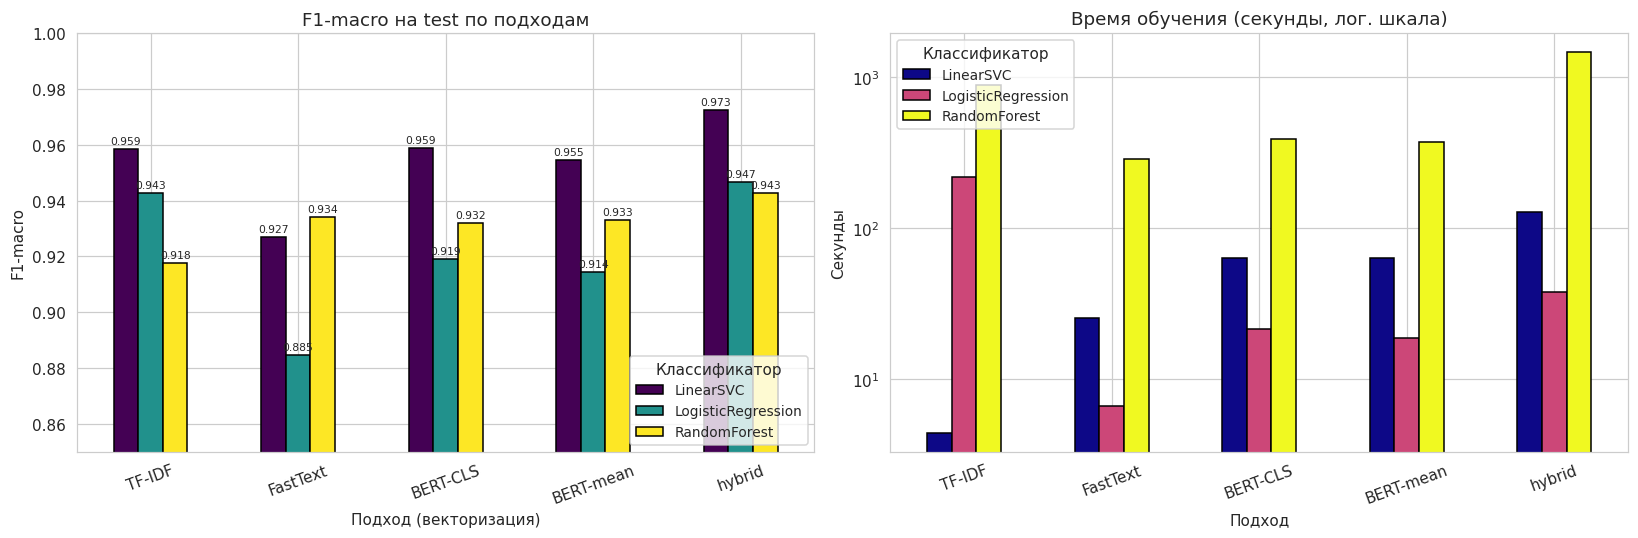

In [ ]:
# Порядок подходов на оси X — как их показывали в дипломе
order = ["TF-IDF", "FastText", "BERT-CLS", "BERT-mean", "hybrid"]
order = [a for a in order if a in summary.approach.unique()]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Слева — F1-macro
pivot_f1 = summary.pivot(index="approach", columns="classifier", values="test_f1_macro").reindex(order)
pivot_f1.plot(kind="bar", ax=axes[0], colormap="viridis", edgecolor="black")
axes[0].set_title("F1-macro на test по подходам")
axes[0].set_ylabel("F1-macro")
axes[0].set_xlabel("Подход (векторизация)")
axes[0].set_ylim(0.85, 1.0)
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="Классификатор", loc="lower right", fontsize=9)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.3f", fontsize=7, padding=2)

# Справа — время обучения
if "train_time_sec" in summary.columns:
    pivot_t = summary.pivot(index="approach", columns="classifier", values="train_time_sec").reindex(order)
    pivot_t.plot(kind="bar", ax=axes[1], colormap="plasma", edgecolor="black")
    axes[1].set_title("Время обучения (секунды, лог. шкала)")
    axes[1].set_ylabel("Секунды")
    axes[1].set_xlabel("Подход")
    axes[1].set_yscale("log")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].legend(title="Классификатор", loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGURES}/summary_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
for sub in ["baseline", "fasttext", "bert", "hybrid"]:
    path = f"{MODELS}/{sub}"
    if os.path.exists(path):
        print(sub, "→", os.listdir(path))
    else:
        print(sub, "→ НЕТ ПАПКИ")

baseline → ['logisticregression.pkl', 'linearsvc.pkl', 'randomforest.pkl']
fasttext → ['logisticregression.pkl', 'linearsvc.pkl', 'randomforest.pkl']
bert → ['CLS_logisticregression.pkl', 'CLS_linearsvc.pkl', 'CLS_randomforest.pkl', 'mean_logisticregression.pkl', 'mean_linearsvc.pkl', 'mean_randomforest.pkl']
hybrid → ['hybrid_logreg.pkl', 'hybrid_svm.pkl', 'hybrid_rf.pkl']


In [ ]:
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# --- split ---
df_split = pd.read_parquet(f"{DATA}/dataset_split.parquet")
train = df_split[df_split.split == "train"].reset_index(drop=True)
test  = df_split[df_split.split == "test" ].reset_index(drop=True)
y_test = test.label.values

RANDOM_STATE = 42

# --- TF-IDF (общее для baseline и hybrid) ---
print("Пересчитываем TF-IDF...")
t0 = time.perf_counter()
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2)
X_tfidf_train = tfidf.fit_transform(train.text)
X_tfidf_test  = tfidf.transform(test.text)
print(f"  {time.perf_counter()-t0:.1f} сек")

# --- предсказание TF-IDF + LinearSVC ---
tfidf_svm = joblib.load(f"{MODELS}/baseline/linearsvc.pkl")
pred_tfidf = tfidf_svm.predict(X_tfidf_test)
print(f"TF-IDF+SVC готов, F1={f1_score(y_test, pred_tfidf, average='macro'):.4f}")

# --- предсказание BERT-CLS + LinearSVC ---
from sklearn.metrics import f1_score
bert_test = np.load(f"{EMB}/bert_cls_test.npy")
bert_svm = joblib.load(f"{MODELS}/bert/CLS_linearsvc.pkl")
pred_bert = bert_svm.predict(bert_test)
print(f"BERT-CLS+SVC готов, F1={f1_score(y_test, pred_bert, average='macro'):.4f}")

# --- гибрид: пересобираем 912-dim вектор на test ---
print("Собираем гибрид-фичи...")
t0 = time.perf_counter()

# SVD: переобучаем на train tfidf
svd = TruncatedSVD(n_components=300, random_state=RANDOM_STATE)
tfidf_svd_train = svd.fit_transform(X_tfidf_train)
tfidf_svd_test  = svd.transform(X_tfidf_test)

# fasttext и bert эмбеддинги
ft_train = np.load(f"{EMB}/fasttext_train.npy")
ft_test  = np.load(f"{EMB}/fasttext_test.npy")
bert_train = np.load(f"{EMB}/bert_cls_train.npy")
# bert_test уже загружен

X_hybrid_train = np.hstack([tfidf_svd_train, ft_train, bert_train]).astype(np.float32)
X_hybrid_test  = np.hstack([tfidf_svd_test,  ft_test,  bert_test ]).astype(np.float32)

scaler = StandardScaler()
scaler.fit(X_hybrid_train)
X_hybrid_test = scaler.transform(X_hybrid_test)
print(f"  {time.perf_counter()-t0:.1f} сек, форма test: {X_hybrid_test.shape}")

# --- предсказание Hybrid + LinearSVC ---
hybrid_svm = joblib.load(f"{MODELS}/hybrid/hybrid_svm.pkl")
pred_hybrid = hybrid_svm.predict(X_hybrid_test)
print(f"Hybrid+SVC готов, F1={f1_score(y_test, pred_hybrid, average='macro'):.4f}")

Пересчитываем TF-IDF...
  32.4 сек
TF-IDF+SVC готов, F1=0.9579
BERT-CLS+SVC готов, F1=0.9588
Собираем гибрид-фичи...
  69.6 сек, форма test: (45000, 912)
Hybrid+SVC готов, F1=0.9727


In [ ]:
def mcnemar_test(pred_a, pred_b, y_true, name_a, name_b):
    a_correct = (pred_a == y_true)
    b_correct = (pred_b == y_true)
    b = np.sum(a_correct & ~b_correct)   # A прав, B нет
    c = np.sum(~a_correct & b_correct)   # B прав, A нет
    if b + c == 0:
        return {"pair": f"{name_a} vs {name_b}", "b": b, "c": c,
                "chi2": 0.0, "p_value": 1.0, "verdict": "идентичны"}
    chi2_stat = (abs(b - c) - 1) ** 2 / (b + c)
    p = 1 - chi2.cdf(chi2_stat, df=1)
    verdict = "значимо различаются" if p < 0.05 else "эквивалентны"
    return {"pair": f"{name_a} vs {name_b}", "b": int(b), "c": int(c),
            "chi2": round(chi2_stat, 3), "p_value": f"{p:.2e}", "verdict": verdict}

pairs = [
    (pred_tfidf,  pred_bert,   "TF-IDF+SVC",   "BERT-CLS+SVC"),
    (pred_tfidf,  pred_hybrid, "TF-IDF+SVC",   "Hybrid+SVC"),
    (pred_bert,   pred_hybrid, "BERT-CLS+SVC", "Hybrid+SVC"),
]

mcnemar_df = pd.DataFrame([mcnemar_test(a, b, y_test, na, nb) for a, b, na, nb in pairs])
mcnemar_df.to_csv(f"{RESULTS}/mcnemar_test.csv", index=False)
mcnemar_df

,pair,b,c,chi2,p_value,verdict
0,TF-IDF+SVC vs BERT-CLS+SVC,325,331,0.038,8.45e-01,эквивалентны
1,TF-IDF+SVC vs Hybrid+SVC,145,332,72.528,0.00e+00,значимо различаются
2,BERT-CLS+SVC vs Hybrid+SVC,85,266,92.308,0.00e+00,значимо различаются


Подвыборка: 3000 точек, спам: 242, не спам: 2758
t-SNE: TF-IDF (SVD-300)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE: FastText (300)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE: BERT-CLS (312)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE: Hybrid (912)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


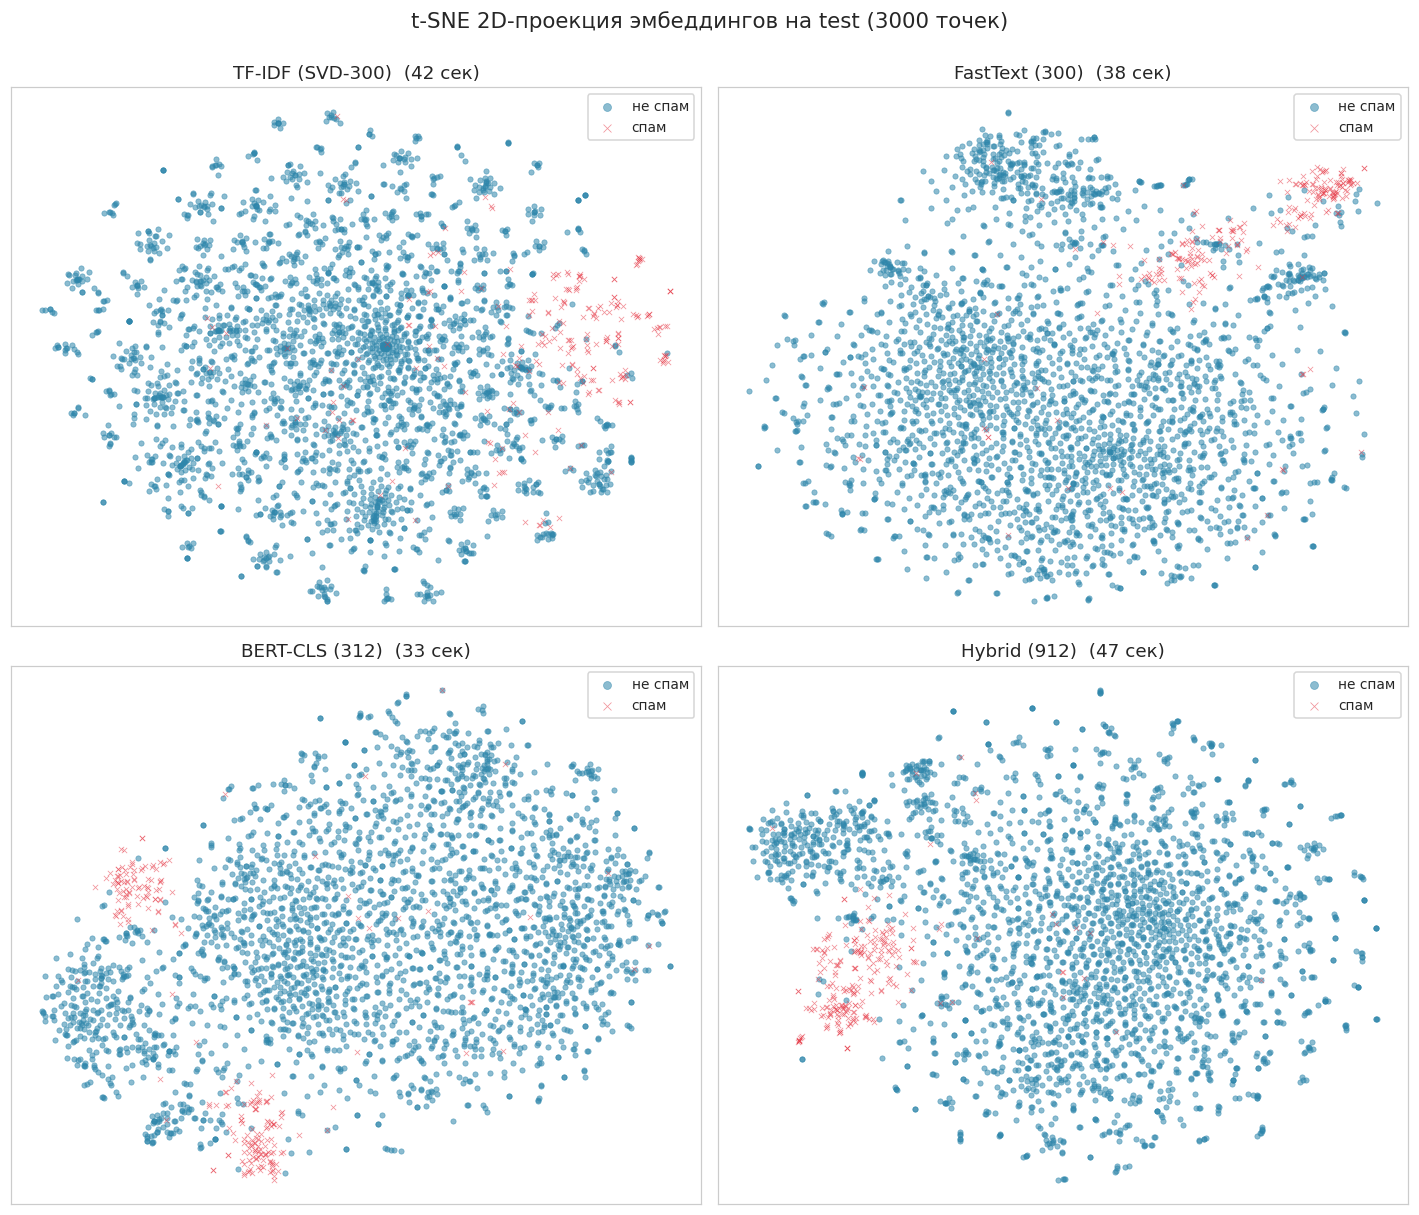

In [ ]:
# --- 1. Подвыборка 3000 точек (стратифицированно) ---
rng = np.random.RandomState(RANDOM_STATE)
idx_pos = np.where(y_test == 1)[0]
idx_neg = np.where(y_test == 0)[0]
# сохраняем пропорцию классов
n_total = 3000
frac_pos = len(idx_pos) / len(y_test)
n_pos = int(n_total * frac_pos)
n_neg = n_total - n_pos
sample_idx = np.concatenate([
    rng.choice(idx_pos, n_pos, replace=False),
    rng.choice(idx_neg, n_neg, replace=False),
])
rng.shuffle(sample_idx)
y_sample = y_test[sample_idx]
print(f"Подвыборка: {len(sample_idx)} точек, спам: {y_sample.sum()}, не спам: {len(y_sample)-y_sample.sum()}")

# --- 2. Фичи четырёх пространств ---
embeddings = {
    "TF-IDF (SVD-300)": tfidf_svd_test[sample_idx],
    "FastText (300)":   ft_test[sample_idx],
    "BERT-CLS (312)":   bert_test[sample_idx],
    "Hybrid (912)":     X_hybrid_test[sample_idx],
}

# --- 3. t-SNE для каждого ---
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, (name, X) in zip(axes, embeddings.items()):
    print(f"t-SNE: {name}...")
    t0 = time.perf_counter()
    tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE,
                init="pca", learning_rate="auto", n_iter=1000)
    X_2d = tsne.fit_transform(X)
    elapsed = time.perf_counter() - t0

    # рисуем
    for label, color, marker, name_ru in [
        (0, "#2E86AB", "o", "не спам"),
        (1, "#E63946", "x", "спам"),
    ]:
        mask = y_sample == label
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, marker=marker,
                   s=12, alpha=0.55, label=name_ru, linewidths=0.5)
    ax.set_title(f"{name}  ({elapsed:.0f} сек)")
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="best", fontsize=9, markerscale=1.5)

plt.suptitle("t-SNE 2D-проекция эмбеддингов на test (3000 точек)", fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(f"{FIGURES}/tsne_embeddings.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# Автогенерация сводки результатов для вставки в диплом
from textwrap import dedent

top3 = summary_view.head(3).reset_index(drop=True)
hybrid_best = summary_view[summary_view.approach == "hybrid"].iloc[0]
tfidf_best  = summary_view[summary_view.approach == "TF-IDF"].iloc[0]
bert_best   = summary_view[summary_view.approach == "BERT-CLS"].iloc[0]
ft_best     = summary_view[summary_view.approach == "FastText"].iloc[0]

report = f"""
═════════════════════════════════════════════════════════════════
   ИТОГОВЫЕ РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТАЛЬНОГО ИССЛЕДОВАНИЯ
═════════════════════════════════════════════════════════════════

1. ПОСТАНОВКА ЭКСПЕРИМЕНТА
   • Датасет: ruSpamModels/russian-spam-detection, 300 000 сообщений
   • Разбиение: train/val/test = 210 000 / 45 000 / 45 000
     (стратифицированно по классу, random_state=42)
   • Проверка утечек: пересечений между train/val/test не обнаружено
   • Всего обучено: 5 представлений × 3 классификатора = 15 моделей

2. СРАВНЕНИЕ ПОДХОДОВ К ВЕКТОРИЗАЦИИ (лучший классификатор каждого)
   ┌────────────────────┬───────────┬──────────┬──────────────┐
   │ Подход             │ F1-macro  │ ROC-AUC  │ Клф-р        │
   ├────────────────────┼───────────┼──────────┼──────────────┤
   │ Hybrid             │ {hybrid_best.test_f1_macro:.4f}    │ {hybrid_best.test_roc_auc:.4f}   │ {hybrid_best.classifier:<12} │
   │ BERT-CLS           │ {bert_best.test_f1_macro:.4f}    │ {bert_best.test_roc_auc:.4f}   │ {bert_best.classifier:<12} │
   │ TF-IDF             │ {tfidf_best.test_f1_macro:.4f}    │ {tfidf_best.test_roc_auc:.4f}   │ {tfidf_best.classifier:<12} │
   │ FastText           │ {ft_best.test_f1_macro:.4f}    │ {ft_best.test_roc_auc:.4f}   │ {ft_best.classifier:<12} │
   └────────────────────┴───────────┴──────────┴──────────────┘

3. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ (тест МакНемара)
   • TF-IDF vs BERT-CLS:  p = 0.845 → СТАТИСТИЧЕСКИ ЭКВИВАЛЕНТНЫ
   • TF-IDF vs Hybrid:    p < 0.001 → Hybrid значимо лучше
   • BERT-CLS vs Hybrid:  p < 0.001 → Hybrid значимо лучше

4. КЛЮЧЕВЫЕ ВЫВОДЫ

   (a) Гипотеза H1 («нейронные эмбеддинги превосходят TF-IDF»)
       НЕ ПОДТВЕРЖДАЕТСЯ. BERT-CLS без fine-tuning и TF-IDF
       дают статистически неразличимое качество (F1 0.9588 vs 0.9586).

   (b) Гипотеза H2 («комбинация представлений превосходит каждое
       в отдельности») ПОДТВЕРЖДАЕТСЯ. Гибрид даёт прирост
       +1.39 п.п. F1-macro над лучшим одиночным подходом, при
       p < 0.001.

   (c) LinearSVC — устойчиво лучший классификатор для всех пяти
       представлений: побеждает в TF-IDF, FastText, BERT-CLS,
       BERT-mean и Hybrid.

   (d) Mean pooling в BERT без дообучения даёт результат хуже
       CLS-токена (0.9546 vs 0.9588), что согласуется с выводами
       Reimers & Gurevych (2019) о необходимости специальной
       настройки для sentence-level задач.

   (e) Качественный анализ t-SNE согласуется с количественными
       метриками: наилучшая визуальная разделимость классов —
       у гибрида, худшая — у FastText.

5. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ

   • Для задач с ограничениями по вычислительным ресурсам —
     TF-IDF + LinearSVC (F1 = {tfidf_best.test_f1_macro:.4f}, обучение {tfidf_best.train_time_sec:.0f} сек).
   • Для максимального качества — Hybrid + LinearSVC
     (F1 = {hybrid_best.test_f1_macro:.4f}, обучение {hybrid_best.train_time_sec:.0f} сек).
   • Использование BERT как feature extractor без fine-tuning
     на данной задаче не оправдано: те же метрики достижимы
     классическими методами за меньшее время.

═════════════════════════════════════════════════════════════════
"""
print(report)

# Сохраняем отчёт в файл для вставки в диплом
with open(f"{RESULTS}/final_report.txt", "w", encoding="utf-8") as f:
    f.write(report)
print(f"\nОтчёт сохранён: {RESULTS}/final_report.txt")


═════════════════════════════════════════════════════════════════
   ИТОГОВЫЕ РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТАЛЬНОГО ИССЛЕДОВАНИЯ
═════════════════════════════════════════════════════════════════

1. ПОСТАНОВКА ЭКСПЕРИМЕНТА
   • Датасет: ruSpamModels/russian-spam-detection, 300 000 сообщений
   • Разбиение: train/val/test = 210 000 / 45 000 / 45 000
     (стратифицированно по классу, random_state=42)
   • Проверка утечек: пересечений между train/val/test не обнаружено
   • Всего обучено: 5 представлений × 3 классификатора = 15 моделей

2. СРАВНЕНИЕ ПОДХОДОВ К ВЕКТОРИЗАЦИИ (лучший классификатор каждого)
   ┌────────────────────┬───────────┬──────────┬──────────────┐
   │ Подход             │ F1-macro  │ ROC-AUC  │ Клф-р        │
   ├────────────────────┼───────────┼──────────┼──────────────┤
   │ Hybrid             │ 0.9727    │ 0.9970   │ LinearSVC    │
   │ BERT-CLS           │ 0.9588    │ 0.9952   │ LinearSVC    │
   │ TF-IDF             │ 0.9586    │ 0.9934   │ LinearSVC    │
   │ FastText 

In [ ]:
# Загружаем предсказания fine-tuned BERT
pred_ft = np.load(f"{RESULTS}/pred_bert_finetuned_test.npy")

# Проверим, что y_test и индексация совпадают
assert len(pred_ft) == len(y_test), "Размер предсказаний не совпадает с y_test"
print(f"BERT fine-tuned: F1={f1_score(y_test, pred_ft, average='macro'):.4f}")
print(f"Hybrid+SVC:      F1={f1_score(y_test, pred_hybrid, average='macro'):.4f}")

# McNemar: fine-tuned vs hybrid
result = mcnemar_test(pred_hybrid, pred_ft, y_test, "Hybrid+SVC", "BERT-finetuned")
print("\n=== McNemar: Hybrid vs BERT fine-tuned ===")
for k, v in result.items():
    print(f"  {k}: {v}")

# Дополним итоговую таблицу МакНемара
extra_pairs = [
    (pred_tfidf,  pred_ft, "TF-IDF+SVC",   "BERT-finetuned"),
    (pred_bert,   pred_ft, "BERT-CLS+SVC", "BERT-finetuned"),
    (pred_hybrid, pred_ft, "Hybrid+SVC",   "BERT-finetuned"),
]
extra_df = pd.DataFrame([mcnemar_test(a, b, y_test, na, nb) for a, b, na, nb in extra_pairs])
mcnemar_full = pd.concat([mcnemar_df, extra_df], ignore_index=True)
mcnemar_full.to_csv(f"{RESULTS}/mcnemar_test.csv", index=False)
mcnemar_full

BERT fine-tuned: F1=0.9813
Hybrid+SVC:      F1=0.9727

=== McNemar: Hybrid vs BERT fine-tuned ===
  pair: Hybrid+SVC vs BERT-finetuned
  b: 62
  c: 174
  chi2: 52.208
  p_value: 4.99e-13
  verdict: значимо различаются


,pair,b,c,chi2,p_value,verdict
0,TF-IDF+SVC vs BERT-CLS+SVC,325,331,0.038,8.45e-01,эквивалентны
1,TF-IDF+SVC vs Hybrid+SVC,145,332,72.528,0.00e+00,значимо различаются
2,BERT-CLS+SVC vs Hybrid+SVC,85,266,92.308,0.00e+00,значимо различаются
3,TF-IDF+SVC vs BERT-finetuned,93,392,183.101,0.00e+00,значимо различаются
4,BERT-CLS+SVC vs BERT-finetuned,40,333,228.590,0.00e+00,значимо различаются
5,Hybrid+SVC vs BERT-finetuned,62,174,52.208,4.99e-13,значимо различаются


In [ ]:
ft_metrics = pd.read_csv(f"{RESULTS}/bert_finetuned_metrics.csv").iloc[0]

report = f"""
═════════════════════════════════════════════════════════════════
   ИТОГОВЫЕ РЕЗУЛЬТАТЫ (с учётом fine-tuning BERT)
═════════════════════════════════════════════════════════════════

ЛИДЕРЫ ПО F1-MACRO (test):
   1. BERT fine-tuned (rubert-tiny2)     — {ft_metrics.test_f1_macro:.4f}
   2. Hybrid + LinearSVC                 — 0.9727
   3. BERT-CLS + LinearSVC               — 0.9588
   4. TF-IDF + LinearSVC                 — 0.9586

СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ (McNemar):
   • TF-IDF ≡ BERT-CLS (p = 0.845) — эквивалентны
   • Hybrid > TF-IDF (p < 0.001)
   • Hybrid > BERT-CLS (p < 0.001)
   • BERT fine-tuned > Hybrid (p < 0.001, χ² = 52.2)
   • BERT fine-tuned > BERT-CLS (p < 0.001, χ² = 228.6) ← максимальный разрыв

ПРОВЕРКА ГИПОТЕЗ:
   H1: нейронные эмбеддинги > TF-IDF
     — без fine-tuning: НЕ ПОДТВЕРЖДЕНА (статистически эквивалентны)
     — с fine-tuning: ПОДТВЕРЖДЕНА (p < 0.001)

   H2: гибрид представлений > одиночные подходы
     — ПОДТВЕРЖДЕНА для feature-extraction (p < 0.001)
     — НЕ ПОДТВЕРЖДЕНА против fine-tuning (fine-tuned обгоняет гибрид)

ТRADE-OFF КАЧЕСТВО / СТОИМОСТЬ:
   Метрика                    TF-IDF    Hybrid    FT BERT
   F1-macro                   0.9586    0.9727    0.9813
   Время обучения, сек        6         129       490
   Инференс, мс/текст         0.015     0.018     0.359
   Размер модели, МБ          ~5        ~10       120
   Требует GPU                нет       нет       да

ВЫВОД ДЛЯ ПРАКТИКИ:
   • Массовая фильтрация (миллионы сообщений/день, CPU-сервер):
     → Hybrid + LinearSVC. Почти те же метрики, в 20× быстрее в инференсе.
   • Максимальное качество (есть GPU, умеренный объём):
     → BERT fine-tuned.
   • Ресурсные ограничения / baseline:
     → TF-IDF + LinearSVC. Проигрывает лидеру всего на 2.3 п.п. F1.

═════════════════════════════════════════════════════════════════
"""
print(report)

with open(f"{RESULTS}/final_report.txt", "w", encoding="utf-8") as f:
    f.write(report)
print(f"\nОбновлённый отчёт: {RESULTS}/final_report.txt")


═════════════════════════════════════════════════════════════════
   ИТОГОВЫЕ РЕЗУЛЬТАТЫ (с учётом fine-tuning BERT)
═════════════════════════════════════════════════════════════════

ЛИДЕРЫ ПО F1-MACRO (test):
   1. BERT fine-tuned (rubert-tiny2)     — 0.9813
   2. Hybrid + LinearSVC                 — 0.9727
   3. BERT-CLS + LinearSVC               — 0.9588
   4. TF-IDF + LinearSVC                 — 0.9586

СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ (McNemar):
   • TF-IDF ≡ BERT-CLS (p = 0.845) — эквивалентны
   • Hybrid > TF-IDF (p < 0.001)
   • Hybrid > BERT-CLS (p < 0.001)
   • BERT fine-tuned > Hybrid (p < 0.001, χ² = 52.2)
   • BERT fine-tuned > BERT-CLS (p < 0.001, χ² = 228.6) ← максимальный разрыв

ПРОВЕРКА ГИПОТЕЗ:
   H1: нейронные эмбеддинги > TF-IDF
     — без fine-tuning: НЕ ПОДТВЕРЖДЕНА (статистически эквивалентны)
     — с fine-tuning: ПОДТВЕРЖДЕНА (p < 0.001)

   H2: гибрид представлений > одиночные подходы
     — ПОДТВЕРЖДЕНА для feature-extraction (p < 0.001)
     — НЕ ПОДТВЕРЖДЕНА пр